DYNAMIC PROGRAMMING: Value Iteration (BIS Error + deltaBIS)
✓ Found existing agent at artifacts\dp_bis_deltabis_agent.npz, will warm-start Value Iteration.

Computing Transition Matrix (P) and Rewards (R)...
✓ Transition matrix computed

Executing Value Iteration...
✓ Converged at episode 1, step 1

Extracting optimal policy...

✓ Saved DP agent to artifacts\dp_bis_deltabis_agent.npz


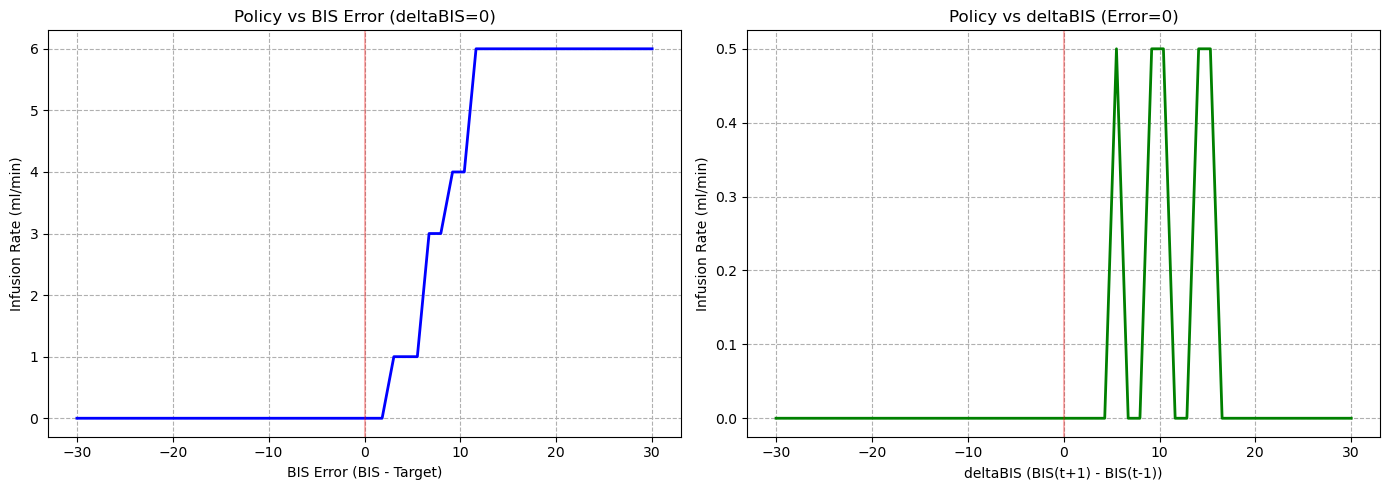

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================

EPISODES = 1000000
GAMMA = 0.69
STEPS_PER_EPISODE = 120
FORCE_RETRAIN = True
MIN_EPISODES_BEFORE_STOP = 50
CONVERGENCE_TOL = 1e-6
# ============================================================================
# PK/PD PARAMETERS (Schnider Model)
# ============================================================================

V1, V2, V3 = 4.27, 18.9, 238.0
k10, k12, k21, k13, k31 = 0.38, 0.30, 0.20, 0.19, 0.0035
ke0 = 0.17
BIS_0, BIS_MAX, EC50, HILL = 95.0, 75.0, 3.5, 2.5
BIS_TARGET = 50.0

# ============================================================================
# RL CONFIGURATION
# ============================================================================

ACTIONS = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0]
BINS_PER_FEAT = 10
NUM_STATES = BINS_PER_FEAT**6  # 1,000,000 states (6 fuzzy features, each with 10 bins)

# ============================================================================
# EVALUATION CONFIGURATION
# ============================================================================

EVAL_SAMPLE_SIZE = 500
EVAL_EPISODE_LENGTHS = [300, 600, 1200, 3600]
EVAL_TIME_STEP = 5 / 60
RANDOM_SEED = 42

AGE_GROUPS = {
    "25-29": (25, 29),
    "30-45": (30, 45),
    "46-60": (46, 60),
    "60-80": (60, 80),
    "80+": (80, 120),
}

# ============================================================================
# PATHS
# ============================================================================

ARTIFACTS_DIR = Path("artifacts")
METRICS_DIR = Path("metrics")
DATA_PATH = Path("data/Patients Data.csv")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
DP_PATH = ARTIFACTS_DIR / "dp_bis_deltabis_agent.npz"

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def get_fuzzy_features(bis_error, deltabis):
    """Build fuzzy features from BIS error and deltaBIS."""
    error_scaled = np.clip(bis_error / 20.0, -1, 1)
    mu_error_neg = max(0, -error_scaled)
    mu_error_zero = max(0, 1.0 - abs(error_scaled))
    mu_error_pos = max(0, error_scaled)

    delta_scaled = np.clip(deltabis / 20.0, -1, 1)
    mu_delta_neg = max(0, -delta_scaled)
    mu_delta_zero = max(0, 1.0 - abs(delta_scaled))
    mu_delta_pos = max(0, delta_scaled)

    return np.array([mu_error_neg, mu_error_zero, mu_error_pos, mu_delta_neg, mu_delta_zero, mu_delta_pos])


def state_to_idx(features):
    """Map fuzzy features to integer state index in [0, NUM_STATES-1]."""
    features = np.asarray(features)
    if features.shape != (6,):
        raise ValueError(f"features must be length-6 vector, got shape {features.shape}")

    bins = np.clip((features * (BINS_PER_FEAT - 1)), 0, BINS_PER_FEAT - 1).astype(int)
    idx = 0
    for b in bins:
        idx = idx * BINS_PER_FEAT + int(b)
    return idx


def get_ce_from_error(bis_error):
    """Inverse PD relation to estimate Ce from BIS error."""
    bis = bis_error + BIS_TARGET
    ratio = (BIS_0 - bis) / BIS_MAX
    ratio = np.clip(ratio, 0.01, 0.99)
    ce = EC50 * (ratio / (1 - ratio)) ** (1 / HILL)
    return ce

# ============================================================================
# DP ALGORITHM: TRAINING SECTION
# ============================================================================

print("=" * 70)
print("DYNAMIC PROGRAMMING: Value Iteration (BIS Error + deltaBIS)")
print("=" * 70)

loaded_V = None
if DP_PATH.exists() and not FORCE_RETRAIN:
    try:
        data = np.load(DP_PATH)
        loaded_V = data["V"]
        print(f"✓ Found existing agent at {DP_PATH}, will warm-start Value Iteration.")
    except Exception as e:
        print(f"Could not load existing agent: {e}")
elif DP_PATH.exists() and FORCE_RETRAIN:
    print(f"↺ FORCE_RETRAIN=True: ignoring existing agent at {DP_PATH} and training from scratch.")

print("\nComputing Transition Matrix (P) and Rewards (R)...")
P = np.zeros((NUM_STATES, len(ACTIONS)), dtype=int)
R = np.zeros((NUM_STATES, len(ACTIONS)))

for s in range(NUM_STATES):
    bins = np.array([
        s // (BINS_PER_FEAT**5),
        (s // (BINS_PER_FEAT**4)) % BINS_PER_FEAT,
        (s // (BINS_PER_FEAT**3)) % BINS_PER_FEAT,
        (s // (BINS_PER_FEAT**2)) % BINS_PER_FEAT,
        (s // BINS_PER_FEAT) % BINS_PER_FEAT,
        s % BINS_PER_FEAT,
    ], dtype=float)
    features = bins / (BINS_PER_FEAT - 1)

    bis_error = (features[2] - features[0]) * 30
    deltabis = (features[5] - features[3]) * 30

    for a_idx, infusion in enumerate(ACTIONS):
        bis_error_next = bis_error - (infusion / max(ACTIONS)) * 15
        deltabis_next = deltabis - (infusion / max(ACTIONS)) * 10

        bis_error_next = np.clip(bis_error_next, -30, 30)
        deltabis_next = np.clip(deltabis_next, -30, 30)

        features_next = get_fuzzy_features(bis_error_next, deltabis_next)
        s_next = state_to_idx(features_next)

        P[s, a_idx] = s_next
        R[s, a_idx] = -(abs(bis_error_next) + 0.5 * abs(deltabis_next))

print("✓ Transition matrix computed")

print("\nExecuting Value Iteration...")
if loaded_V is not None and loaded_V.shape == (NUM_STATES,):
    V = loaded_V.copy()
else:
    V = np.zeros(NUM_STATES)

for ep in range(EPISODES):
    converged = False
    max_delta = 0.0

    for step in range(STEPS_PER_EPISODE):
        V_old = V.copy()
        Q_vals = R + GAMMA * V[P]
        V = np.max(Q_vals, axis=1)

        max_delta = np.max(np.abs(V - V_old))
        if max_delta < CONVERGENCE_TOL and (ep + 1) >= MIN_EPISODES_BEFORE_STOP:
            print(f"✓ Converged at episode {ep + 1}, step {step + 1} (tol={CONVERGENCE_TOL})")
            converged = True
            break

    if (ep + 1) % 100 == 0:
        print(f"  Episode {ep + 1}/{EPISODES}, step {step + 1}/{STEPS_PER_EPISODE}, max change: {max_delta:.6f}")

    if converged:
        break

print("\nExtracting optimal policy...")
Q_vals = R + GAMMA * V[P]
policy = np.argmax(Q_vals, axis=1).astype(int)

np.savez_compressed(
    DP_PATH,
    V=V,
    policy=policy,
    P=P,
    R=R,
    actions=np.array(ACTIONS, dtype=float),
    gamma=np.array([GAMMA], dtype=float),
)
print(f"\n✓ Saved DP agent to {DP_PATH}")

# ============================================================================
# VISUALIZATION: POLICY AND EVALUATION TRACES
# ============================================================================

np.random.seed(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

error_range = np.linspace(-30, 30, 50)
deltabis_fixed = 0.0
chosen_doses_error = []
for err in error_range:
    features = get_fuzzy_features(err, deltabis_fixed)
    s = state_to_idx(features)
    chosen_doses_error.append(ACTIONS[policy[s]])

axes[0].plot(error_range, chosen_doses_error, color="blue", lw=2)
axes[0].set_title("Policy vs BIS Error (deltaBIS=0)")
axes[0].set_xlabel("BIS Error (BIS - Target)")
axes[0].set_ylabel("Infusion Rate (ml/min)")
axes[0].grid(True, linestyle="--")
axes[0].axvline(0, color="red", linestyle="-", alpha=0.3, label="Target")

deltabis_range = np.linspace(-30, 30, 50)
error_fixed = 0.0
chosen_doses_delta = []
for db in deltabis_range:
    features = get_fuzzy_features(error_fixed, db)
    s = state_to_idx(features)
    chosen_doses_delta.append(ACTIONS[policy[s]])

axes[1].plot(deltabis_range, chosen_doses_delta, color="green", lw=2)
axes[1].set_title("Policy vs deltaBIS (Error=0)")
axes[1].set_xlabel("deltaBIS (BIS(t+1) - BIS(t-1))")
axes[1].set_ylabel("Infusion Rate (ml/min)")
axes[1].grid(True, linestyle="--")
axes[1].axvline(0, color="red", linestyle="-", alpha=0.3, label="Target")

plt.tight_layout()
plt.show()

# EVALUATION ON POPULATION DATASET

In [9]:
import pandas as pd
import random

from utils.eval_metrics import (
    calculate_bis_metrics,
    get_age_group,
    create_results_dataframe,
    create_summary_by_age_group,
    save_evaluation_results,
)

# ============================================================================
# DATA LOADING AND PREPROCESSING
# ============================================================================

def load_data(path):
    return pd.read_csv(path)


def preprocess_data(df):
    df = df.copy()

    def parse_age(x):
        try:
            parts = str(x).strip().split(" ")
            if len(parts) < 2:
                return 50
            low = int(parts[1])
            if len(parts) > 3:
                high = 100 if parts[3] == "older" else int(parts[3])
                return int(random.randrange(low, high))
            return int(low)
        except Exception:
            return 50

    if "AgeCategory" in df.columns:
        df.loc[:, "AgeCategory"] = df["AgeCategory"].apply(parse_age)
    return df


def schnider_model(age, weight, height, sex):
    sex = str(sex).lower()
    if sex == "male":
        lbm = 1.10 * weight - 128 * (weight**2) / (height**2)
    else:
        lbm = 1.07 * weight - 148 * (weight**2) / (height**2)

    V1_s = 4.27
    V2_s = 18.9 - 0.391 * (age - 53)
    k10_s = 0.443 + 0.0107 * (weight - 77) - 0.0159 * (lbm - 59) + 0.0062 * (height - 177)
    k12_s = 0.302 - 0.0056 * (age - 53)
    k13_s = 0.196
    k21_s = (1.29 - 0.024 * (age - 53)) / V2_s
    k31_s = 0.0035
    ke0_s = 0.456

    A = np.array(
        [
            [-(k10_s + k12_s + k13_s), k21_s, k31_s, 0],
            [k12_s, -k21_s, 0, 0],
            [k13_s, 0, -k31_s, 0],
            [ke0_s, 0, 0, -ke0_s],
        ],
        dtype=float,
    )
    B = np.array([[1 / V1_s], [0], [0], [0]], dtype=float)
    return {"A": A, "B": B}


def generate_schnider_dataset(df):
    params_list = []
    for _, row in df.iterrows():
        params = schnider_model(
            age=row["AgeCategory"],
            weight=row["WeightInKilograms"],
            height=row["HeightInMeters"],
            sex=row["Sex"],
        )
        params_list.append(params)

    params_df = pd.DataFrame(params_list)
    return pd.concat([df.reset_index(drop=True), params_df], axis=1)


# ============================================================================
# EVALUATOR CLASS
# ============================================================================

class DPEvaluator:
    def __init__(self, policy, actions):
        self.policy = policy
        self.actions = actions
        self.target = BIS_TARGET
        self.bis0 = BIS_0
        self.bis_max = BIS_MAX
        self.ec50 = EC50
        self.hill = HILL
        self.bins_per_feat = BINS_PER_FEAT

    def _get_state_idx(self, bis_error, deltabis):
        error_scaled = np.clip(bis_error / 20.0, -1, 1)
        mu_error_neg = max(0, -error_scaled)
        mu_error_zero = max(0, 1.0 - abs(error_scaled))
        mu_error_pos = max(0, error_scaled)

        delta_scaled = np.clip(deltabis / 20.0, -1, 1)
        mu_delta_neg = max(0, -delta_scaled)
        mu_delta_zero = max(0, 1.0 - abs(delta_scaled))
        mu_delta_pos = max(0, delta_scaled)

        features = np.array([mu_error_neg, mu_error_zero, mu_error_pos, mu_delta_neg, mu_delta_zero, mu_delta_pos])

        bins = np.clip((features * (self.bins_per_feat - 1)), 0, self.bins_per_feat - 1).astype(int)
        idx = 0
        for b in bins:
            idx = idx * self.bins_per_feat + int(b)
        return min(idx, len(self.policy) - 1)

    def simulate(self, patient_row, duration_seconds):
        duration_steps = int(duration_seconds / 5)

        A = np.asarray(patient_row["A"], dtype=float)
        B = np.asarray(patient_row["B"], dtype=float)
        x = np.zeros((4, 1), dtype=float)

        bis_log = []
        bis_prev_prev = self.bis0
        bis_prev = self.bis0

        for t in range(duration_steps):
            ce = np.clip(float(x[3, 0]), 0.0, 10.0)

            ce_h = np.power(ce, self.hill)
            ec50_h = np.power(self.ec50, self.hill)
            if ce_h + ec50_h > 0:
                bis_ideal = self.bis0 - self.bis_max * (ce_h / (ce_h + ec50_h))
            else:
                bis_ideal = self.bis0

            bis_ideal = np.clip(float(bis_ideal), 0, 100)
            measured_bis = np.clip(bis_ideal + np.random.normal(0, 3), 0, 100)

            bis_error = measured_bis - self.target
            deltabis = measured_bis - bis_prev_prev if t > 0 else 0.0
            s_idx = self._get_state_idx(bis_error, deltabis)

            a_idx = int(self.policy[s_idx])
            u = float(self.actions[a_idx])

            x_dot = A @ x + B * u
            x = x + x_dot * EVAL_TIME_STEP
            x = np.clip(x, -10.0, 10.0)

            bis_prev_prev = bis_prev
            bis_prev = measured_bis
            bis_log.append(float(measured_bis))

        return np.array(bis_log)

    def evaluate(self, df_sim, duration_seconds=120 * 60):
        results = []
        for _, patient in df_sim.iterrows():
            bis_traj = self.simulate(patient, duration_seconds)
            metrics = calculate_bis_metrics(bis_traj, self.target)
            results.append(
                {
                    "PatientID": patient.get("PatientID", np.nan),
                    "MDPE": metrics["MDPE"],
                    "MDAPE": metrics["MDAPE"],
                    "Wobble": metrics["Wobble"],
                    "Controlled (%)": metrics["TimeInTarget"],
                }
            )
        return pd.DataFrame(results)


# ============================================================================
# EVALUATION EXECUTION
# ============================================================================

print("\n" + "=" * 70)
print("EVALUATION ON POPULATION DATASET")
print("=" * 70)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"\n1. Loading patient data from {DATA_PATH}...")
df = load_data(DATA_PATH)
df = preprocess_data(df)
print(f"   Loaded {len(df)} patients")

print(f"\n2. Sampling {EVAL_SAMPLE_SIZE} patients...")
sample_df = df.sample(n=min(EVAL_SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED)
print(f"   Sampled {len(sample_df)} patients")

print("\n3. Generating Schnider PK/PD parameters...")
eval_df = generate_schnider_dataset(sample_df)
print(f"   Generated parameters for {len(eval_df)} patients")

print(f"\n4. Loading trained DP agent from {DP_PATH}...")
dp_data = np.load(DP_PATH)
policy_eval = dp_data["policy"]
actions_eval = dp_data["actions"]
print(f"   Loaded policy: shape {policy_eval.shape}")

evaluator = DPEvaluator(policy_eval, actions_eval)

print(f"\n5. Evaluating policy at {len(EVAL_EPISODE_LENGTHS)} episode lengths...")
patient_results = []

for idx, (_, patient) in enumerate(eval_df.iterrows()):
    if (idx + 1) % 50 == 0:
        print(f"   Processing patient {idx + 1}/{len(eval_df)}...")

    patient_id = patient["PatientID"]
    age = patient["AgeCategory"]
    age_group = get_age_group(age, AGE_GROUPS)

    results = {}
    for ep_len in EVAL_EPISODE_LENGTHS:
        bis_traj = evaluator.simulate(patient, ep_len)
        metrics = calculate_bis_metrics(bis_traj, BIS_TARGET)
        results[ep_len] = metrics

    patient_results.append(
        {
            "patient_id": patient_id,
            "age": age,
            "age_group": age_group,
            "results": results,
        }
    )

results_df = create_results_dataframe(patient_results, EVAL_EPISODE_LENGTHS)
summary_df = create_summary_by_age_group(results_df, EVAL_EPISODE_LENGTHS, AGE_GROUPS)

print("\n6. Saving evaluation results...")
save_evaluation_results(
    results_df,
    summary_df,
    "dp_bis_deltabis_agent",
    str(METRICS_DIR),
)

print("\n" + "=" * 70)
print("Evaluation complete!")
print(f"  - Results: {len(results_df)} patients")
print(f"  - Age groups: {results_df['AgeGroup'].nunique()}")
print(f"  - Episode lengths: {len(EVAL_EPISODE_LENGTHS)}")
print("=" * 70)


EVALUATION ON POPULATION DATASET

1. Loading patient data from data\Patients Data.csv...
   Loaded 237630 patients

2. Sampling 500 patients...
   Sampled 500 patients

3. Generating Schnider PK/PD parameters...
   Generated parameters for 500 patients

4. Loading trained DP agent from artifacts\dp_bis_deltabis_agent.npz...
   Loaded policy: shape (1000000,)

5. Evaluating policy at 4 episode lengths...
   Processing patient 50/500...
   Processing patient 100/500...
   Processing patient 150/500...
   Processing patient 200/500...
   Processing patient 250/500...
   Processing patient 300/500...
   Processing patient 350/500...
   Processing patient 400/500...
   Processing patient 450/500...
   Processing patient 500/500...

6. Saving evaluation results...
Saved results to metrics\dp_bis_deltabis_agent_results.json
Saved summary to metrics\dp_bis_deltabis_agent_summary.json

Evaluation complete!
  - Results: 500 patients
  - Age groups: 6
  - Episode lengths: 4


# LOAD AND EVALUATE SAVED DP AGENT

In [10]:
from utils.eval_runner import run_saved_dp_evaluation

results_df = run_saved_dp_evaluation(
    dp_path=DP_PATH,
    evaluator_cls=DPEvaluator,
    load_data_fn=load_data,
    preprocess_data_fn=preprocess_data,
    generate_dataset_fn=generate_schnider_dataset,
    sample_size=100,
)


LOADING SAVED DP AGENT

Loading agent from: artifacts\dp_bis_deltabis_agent.npz
  - Loaded V (value function): shape (1000000,)
  - Loaded policy: shape (1000000,)
  - Loaded P (transitions): shape (1000000, 7)
  - Loaded R (rewards): shape (1000000, 7)
  - Actions available: [0.  0.5 1.  2.  3.  4.  6. ]
  - Gamma (discount): [0.69]

EVALUATING ON POPULATION SAMPLE

Sampling 100 patients from 237630 total...
Generating Schnider parameters for 100 patients...

Running evaluation simulation (120 min per patient)...

EVALUATION RESULTS

Evaluated 100 patients successfully

             MDPE       MDAPE      Wobble  Controlled (%)
count  100.000000  100.000000  100.000000           100.0
mean    89.984640   89.984640    4.050682             0.0
std      0.233030    0.233030    0.127427             0.0
min     89.415586   89.415586    3.791787             0.0
25%     89.831943   89.831943    3.943485             0.0
50%     89.981368   89.981368    4.057370             0.0
75%     90.15267